In [1]:
library(CellChat)
library(Seurat)
library(ggplot2)
library(patchwork)
library(Matrix)
options(stringsAsFactors = FALSE)
options(future.globals.maxSize = 8000 * 1024^2) # Increase to 8GB (or higher)

Warning message:
“package ‘CellChat’ was built under R version 4.4.3”
Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: igraph


Attaching package: ‘igraph’


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Loading required package: ggplot2

Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Loading required package: sp

‘SeuratObject’ was built with package ‘Matrix’ 1.7.2 but the current
version is 1.7.3; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’

# data processing

In [2]:
st1 <- readRDS("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/integration/GW12/1.GW12_obj_annote_bin30.rds")
cellType = c(
    "NPC_proliferative", "NPC", "IPC",  # Neural_progenitor
    "ExN_immature_1", "ExN_immature_2", "ExN_immature_3", "ExN_mature_1", "ExN_mature_2", "ExN_mature_3", "ExN_ventral",  # Excitatory
    "InN_immature_1", "InN_immature_2", "InN_mature_1", "InN_mature_2", "InN_ventral_1", "InN_ventral_2", "InN_ventral_3", #Inhibitory
    "MN1", "MN2", #Motor_neuron
    "APC_cycling", "APC_dorsal", "APC_ventral", "AST", #Astrocyte
    "OPC", "COP", "MFOL", "MOL",  #OLIGODENDROCYTE
    "RP", "MP", "FP",  #Ependymal
    "VLMC",  #VLMC
    "Microglia"  #Microglia
)

# subset 
Idents(st1) <- "celltype"
labels <- Idents(st1)
st1 <- subset(st1, subset = celltype %in% cellType)
st1@meta.data$celltype <- factor(st1@meta.data$celltype, levels = cellType)
Idents(st1) <- "celltype"
labels <- Idents(st1)
st1

Warning message:
“Removing 125 cells missing data for vars requested”


An object of class Seurat 
37322 features across 7907 samples within 1 assay 
Active assay: RNA (37322 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: cod, pca, umap, tsne

In [3]:
st2 <- readRDS("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/integration/GW16/1.GW16_obj_annote_bin30.rds")
cellType = c(
    "NPC_proliferative", "NPC", "IPC",  # Neural_progenitor
    "ExN_immature_1", "ExN_immature_2", "ExN_immature_3", "ExN_mature_1", "ExN_mature_2", "ExN_mature_3", "ExN_ventral",  # Excitatory
    "InN_immature_1", "InN_immature_2", "InN_mature_1", "InN_mature_2", "InN_ventral_1", "InN_ventral_2", "InN_ventral_3", #Inhibitory
    "MN1", "MN2", #Motor_neuron
    "APC_cycling", "APC_dorsal", "APC_ventral", "AST", #Astrocyte
    "OPC", "COP", "MFOL", "MOL",  #OLIGODENDROCYTE
    "RP", "MP", "FP",  #Ependymal
    "VLMC",  #VLMC
    "Microglia"  #Microglia
)
# subset 
Idents(st2) <- "celltype"
labels <- Idents(st2)
st2 <- subset(st2, subset = celltype %in% cellType)
st2@meta.data$celltype <- factor(st2@meta.data$celltype, levels = cellType)
Idents(st2) <- "celltype"
labels <- Idents(st2)
st2

An object of class Seurat 
26991 features across 14464 samples within 1 assay 
Active assay: RNA (26991 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: cod, pca, umap, tsne

In [4]:
st3 <- readRDS("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/integration/GW17/1.GW17_obj_annote_bin30.rds")
cellType = c(
    "NPC_proliferative", "NPC", "IPC",  # Neural_progenitor
    "ExN_immature_1", "ExN_immature_2", "ExN_immature_3", "ExN_mature_1", "ExN_mature_2", "ExN_mature_3", "ExN_ventral",  # Excitatory
    "InN_immature_1", "InN_immature_2", "InN_mature_1", "InN_mature_2", "InN_ventral_1", "InN_ventral_2", "InN_ventral_3", #Inhibitory
    "MN1", "MN2", #Motor_neuron
    "APC_cycling", "APC_dorsal", "APC_ventral", "AST", #Astrocyte
    "OPC", "COP", "MFOL", "MOL",  #OLIGODENDROCYTE
    "RP", "MP", "FP",  #Ependymal
    "VLMC",  #VLMC
    "Microglia"  #Microglia
)
# subset 
Idents(st3) <- "celltype"
labels <- Idents(st3)
st3 <- subset(st3, subset = celltype %in% cellType)
st3@meta.data$celltype <- factor(st3@meta.data$celltype, levels = cellType)
Idents(st3) <- "celltype"
labels <- Idents(st3)
st3

An object of class Seurat 
28357 features across 25632 samples within 1 assay 
Active assay: RNA (28357 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: cod, pca, umap, tsne

In [ ]:
# Prepare input data for CelChat analysis
data.input1 = Seurat::GetAssayData(st1, slot = "data", assay = "RNA") # normalized data matrix
data.input2 = Seurat::GetAssayData(st2, slot = "data", assay = "RNA") # normalized data matrix
data.input3 = Seurat::GetAssayData(st3, slot = "data", assay = "RNA") # normalized data matrix

# gene align
genes.common <- intersect(intersect(rownames(data.input1), rownames(data.input2)), rownames(data.input3))


colnames(data.input1) <- paste0("gw12_", colnames(data.input1))
colnames(data.input2) <- paste0("gw16_", colnames(data.input2))
colnames(data.input3) <- paste0("gw17_", colnames(data.input3))
data.input <- cbind(data.input1[genes.common, ], data.input2[genes.common, ], data.input3[genes.common, ])

# check how many !0 genes
nonzero_genes <- Matrix::rowSums(data.input) > 0
data.input <- data.input[nonzero_genes, ] # 19413 x 48003 sparse Matrix of class "dgCMatrix"

In [8]:
# define the meta data: 
# a column named `samples` should be provided for spatial transcriptomics analysis, which is useful for analyzing cell-cell communication by aggregating multiple samples/replicates. Of note, for comparison analysis across different conditions, users still need to create a CellChat object seperately for each condition.  
meta1 = data.frame(labels = Idents(st1), samples = "gw12") # manually create a dataframe consisting of the cell labels
meta2 = data.frame(labels = Idents(st2), samples = "gw16") 
meta3 = data.frame(labels = Idents(st3), samples = "gw17") 

meta <- rbind(meta1, meta2, meta3)

rownames(meta) <- colnames(data.input)

In [9]:
# a factor level should be defined for the `meta$labels` and `meta$samples`
meta$labels <- factor(meta$labels, levels = levels(Idents(st3)))
meta$samples <- factor(meta$samples, levels = c("gw12", "gw16", "gw17"))

unique(meta$labels) # check the cell labels
# Levels:

unique(meta$samples) # check the sample labels
# Levels:
# 'gw12''gw16''gw17'

[1] ExN_mature_2      NPC               InN_immature_1    ExN_mature_3     
 [5] InN_immature_2    InN_mature_2      ExN_mature_1      InN_mature_1     
 [9] Microglia         InN_ventral_3     ExN_ventral       APC_ventral      
[13] APC_dorsal        NPC_proliferative VLMC              InN_ventral_2    
[17] IPC               APC_cycling       ExN_immature_1    ExN_immature_2   
[21] MN2               InN_ventral_1     ExN_immature_3    OPC              
[25] RP                FP                MOL               MP               
[29] MFOL              COP               MN1               AST              
32 Levels: NPC_proliferative NPC IPC ExN_immature_1 ... Microglia

[1] gw12 gw16 gw17
Levels: gw12 gw16 gw17

In [10]:
# load spatial transcriptomics information
# Spatial locations of spots from full (NOT high/low) resolution images are required. For 10X Visium, this information is in `tissue_positions.csv`. 
spatial.locs1 = st1@meta.data[,c('x','y')]
colnames(spatial.locs1) <- c('imagerow','imagecol')
spatial.locs1$imagerow <- as.integer(spatial.locs1$imagerow); spatial.locs1$imagecol <- as.integer(spatial.locs1$imagecol)

spatial.locs2 = st2@meta.data[,c('x','y')]
colnames(spatial.locs2) <- c('imagerow','imagecol')
spatial.locs2$imagerow <- as.integer(spatial.locs2$imagerow); spatial.locs2$imagecol <- as.integer(spatial.locs2$imagecol)

spatial.locs3 = st3@meta.data[,c('x','y')]
colnames(spatial.locs3) <- c('imagerow','imagecol')
spatial.locs3$imagerow <- as.integer(spatial.locs3$imagerow); spatial.locs3$imagecol <- as.integer(spatial.locs3$imagecol)

spatial.locs <- rbind(spatial.locs1, spatial.locs2, spatial.locs3)

rownames(spatial.locs) <- colnames(data.input)
head(spatial.locs)

,imagerow,imagecol
,<int>,<int>
gw12_GW12:6810_7080,6810,7080
gw12_GW12:6060_5580,6060,5580
gw12_GW12:6570_5940,6570,5940
gw12_GW12:5160_5190,5160,5190
gw12_GW12:4770_6780,4770,6780
gw12_GW12:6510_6060,6510,6060


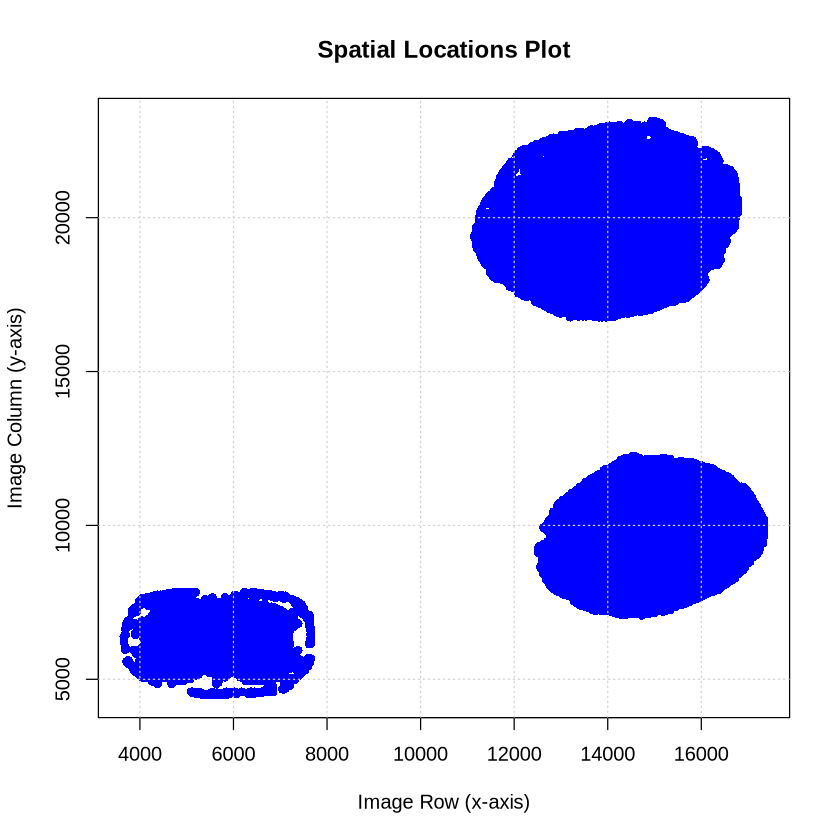

In [11]:
plot(spatial.locs$imagerow, spatial.locs$imagecol,
     xlab = "Image Row (x-axis)", 
     ylab = "Image Column (y-axis)",
     main = "Spatial Locations Plot",
     pch = 16,  # Use solid points
     col = "blue")  # Set point color to blue

# Add grid lines for readability
grid()

In [12]:
spatial.factors = list(tol = 7.5, ratio = 0.5)
# d.spatial <- computeCellDistance(coordinates = spatial.locs, ratio = spatial.factors$ratio, tol = spatial.factors$tol)
# min(d.spatial[d.spatial!=0]) 
#> [1] 15

# analysis

In [13]:
# Create a CellChat object
cellchat <- createCellChat(object = data.input, meta = meta, group.by = "labels",
                           datatype = "spatial", coordinates = data.matrix(spatial.locs), spatial.factors = spatial.factors)
#> [1] "Create a CellChat object from a data matrix"
#> Create a CellChat object from spatial transcriptomics data... 
#> Set cell identities for the new CellChat object 
#> The cell groups used for CellChat analysis are  Astro, L2/3 IT, L4, L5 IT, L6 IT, L6 CT, L6b, Oligo
CellChatDB <- CellChatDB.human # use CellChatDB.mouse if running on mouse data
# use all CellChatDB for cell-cell communication analysis
CellChatDB.use <- CellChatDB # simply use the default CellChatDB. We do not suggest to use it in this way because CellChatDB v2 includes "Non-protein Signaling" (i.e., metabolic and synaptic signaling). 
# set the used database in the object
cellchat@DB <- CellChatDB.use
cellchat

[1] "Create a CellChat object from a data matrix"
Create a CellChat object from spatial transcriptomics data... 
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  NPC_proliferative, NPC, IPC, ExN_immature_1, ExN_immature_2, ExN_immature_3, ExN_mature_1, ExN_mature_2, ExN_mature_3, ExN_ventral, InN_immature_1, InN_immature_2, InN_mature_1, InN_mature_2, InN_ventral_1, InN_ventral_2, InN_ventral_3, MN1, MN2, APC_cycling, APC_dorsal, APC_ventral, AST, OPC, COP, MFOL, MOL, RP, MP, FP, VLMC, Microglia 


An object of class CellChat created from a single dataset 
 19413 genes.
 48003 cells. 
CellChat analysis of spatial data! The input spatial locations are 
                    x_cent y_cent
gw12_GW12:6810_7080   6810   7080
gw12_GW12:6060_5580   6060   5580
gw12_GW12:6570_5940   6570   5940
gw12_GW12:5160_5190   5160   5190
gw12_GW12:4770_6780   4770   6780
gw12_GW12:6510_6060   6510   6060

In [14]:
# subset the expression data of signaling genes for saving computation cost
cellchat <- subsetData(cellchat) # This step is necessary even if using the whole database
future::plan("multisession", workers = 4) 
cellchat <- identifyOverExpressedGenes(cellchat)
cellchat <- identifyOverExpressedInteractions(cellchat)

The number of highly variable ligand-receptor pairs used for signaling inference is 2750 


In [15]:
#> The number of highly variable ligand-receptor pairs used for signaling inference is 2836
# cellchat2 <- computeCommunProb(cellchat, type = "truncatedMean", trim = 0.1,
#                               distance.use = TRUE, interaction.range = 200, scale.distance = 5,
#                               contact.knn.k = 10)

cellchat2 <- computeCommunProb(cellchat, type = "truncatedMean", trim = 0.05, 
                              distance.use = FALSE, interaction.range = 100, scale.distance = NULL,
                              contact.dependent = TRUE, contact.range = 50)

truncatedMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on spatial transcriptomics data without distance values as constraints of the computed communication probability <<< [2026-01-22 17:26:46.904645]"
The input L-R pairs have both secreted signaling and contact-dependent signaling. Run CellChat in a contact-dependent manner for `Cell-Cell Contact` signaling, and in a diffusion manner based on the `interaction.range` for other L-R pairs. 
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2026-01-22 17:39:07.278501]"


In [16]:
#> truncatedMean is used for calculating the average gene expression per cell group. 
#> [1] ">>> Run CellChat on spatial transcriptomics data using distances as constraints of the computed communication probability <<< [2024-02-22 10:39:52.098053]"
#> Molecules of the input L-R pairs are diffusible. Run CellChat in a diffusion manner based on the `interaction.range`.
#> [1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2024-02-22 10:54:30.589965]"
cellchat2 <- computeCommunProbPathway(cellchat2)
cellchat2 <- aggregateNet(cellchat2)
cellchat2 <- netAnalysis_computeCentrality(cellchat2, slot.name = "netP")

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_sapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via the L'Ecuyer-CMRG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_sapply-2’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via the L'Ecuyer-CMRG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "igno

In [17]:
cellchat2@netP$pathways

[1] "NCAM"          "PTN"           "PCDH"          "NRXN"         
 [5] "CypA"          "CD99"          "MK"            "ADGRL"        
 [9] "ADGRG"         "NEGR"          "SLIT"          "NRG"          
[13] "PTPR"          "CNTN"          "GAP"           "CADM"         
[17] "SOMATOSTATIN"  "COLLAGEN"      "L1CAM"         "Prostaglandin"
[21] "Glutamate"     "CDH"           "LAMININ"       "NGL"          
[25] "CLDN"          "SPP1"          "Netrin"        "PSAP"         
[29] "IGF"           "OPIOID"        "PTPRM"         "MAG"          
[33] "AGRN"          "NOTCH"         "Cholesterol"   "JAM"          
[37] "MPZ"           "CD46"          "FLRT"          "FN1"          
[41] "SEMA6"

# Save

In [ ]:
saveRDS(cellchat2, file = "cellchat_stereo_human_spine_ST.rds")

In [81]:
cellchat2 <- readRDS("cellchat_stereo_human_spine_ST.rds")

In [19]:
cellchat2@options$parameter

$type.mean
[1] "truncatedMean"

$trim
[1] 0.05

$raw.use
[1] TRUE

$population.size
[1] FALSE

$nboot
[1] 100

$seed.use
[1] 1

$Kh
[1] 0.5

$n
[1] 1

$distance.use
[1] FALSE

$interaction.range
[1] 100

$ratio
[1] 0.5

$tol
[1] 7.5

$k.min
[1] 10

$contact.dependent
[1] TRUE

$contact.range
[1] 50

$contact.knn.k
NULL

$contact.dependent.forced
[1] FALSE

# plot

In [20]:
# Define color vector
my_colors = c(
    #----------Pro----------
    'NPC_proliferative' = '#D27BA1',
    'NPC' = 'darkgreen',
    'IPC' = '#D10049',

    #----------EX-----------
    'ExN_naive' = '#F2684C',
    'ExN_immature_1' = '#94191D',    
    'ExN_immature_2' = '#31A352',
    'ExN_immature_3' = '#0A0288',
    'ExN_mature_1' = '#6066AF',
    'ExN_mature_2' = '#600073',
    'ExN_mature_3' = '#3182BE',
    'ExN_ventral' = '#9594CB',
    
    #----------IN-----------
    'InN_naive' = '#FFEBB2',
    'InN_immature_1' = '#FFAA7B',
    'InN_immature_2' = '#D0696A',
    'InN_mature_1' = '#841D50',
    'InN_mature_2' = '#E63D53',
    'InN_ventral_1' = '#C2C9D7',
    'InN_ventral_2' = '#CE0011',
    'InN_ventral_3' = '#6D006A',

    #----------MN-----------
    'MN1' = '#8E0B1B',
    'MN2' = '#AEE4EA',

    #---------Astrocyte Precursors & Astrocytes---------
    'APC_cycling' = '#D15500',
    'APC_dorsal' = '#20A6E7',
    'APC_ventral' = '#0055A9',
    'AST' = '#007854',

    #---------Oligodendrocyte Lineage---------
    'OPC' = '#5C5857',
    'COP' = '#83B3D4',
    'MFOL' = '#F0A8B1',
    'MOL' = '#FFD686',

    #---------Ependymal-----------
    'RP' = '#FBA700',
    'MP' = '#F09600',
    'FP' = '#FFDD2A',

    #---------Other-----------
    'VLMC' = '#FEFFC4',
    'EC' = '#eca9b8',
    'Schwann' = '#ba6eac',
    'PC' = '#cb909d',
    'Microglia' = '#DFB8B3'
)

# Define cellType order
cellType = c(
    "NPC_proliferative", "NPC", "IPC",  # Neural_progenitor
    "ExN_immature_1", "ExN_immature_2", "ExN_immature_3", "ExN_mature_1", "ExN_mature_2", "ExN_mature_3", "ExN_ventral",  # Excitatory
    "InN_immature_1", "InN_immature_2", "InN_mature_1", "InN_mature_2", "InN_ventral_1", "InN_ventral_2", "InN_ventral_3", #Inhibitory
    "MN1", "MN2", #Motor_neuron
    "APC_cycling", "APC_dorsal", "APC_ventral", "AST", #Astrocyte
    "OPC", "COP", "MFOL", "MOL",  #OLIGODENDROCYTE
    "RP", "MP", "FP",  #Ependymal
    "VLMC",  #VLMC
    "Microglia"  #Microglia
)

# Extract colors by cellType order
color_list <- my_colors[cellType]
color_list

NPC_proliferative               NPC               IPC    ExN_immature_1 
        "#D27BA1"       "darkgreen"         "#D10049"         "#94191D" 
   ExN_immature_2    ExN_immature_3      ExN_mature_1      ExN_mature_2 
        "#31A352"         "#0A0288"         "#6066AF"         "#600073" 
     ExN_mature_3       ExN_ventral    InN_immature_1    InN_immature_2 
        "#3182BE"         "#9594CB"         "#FFAA7B"         "#D0696A" 
     InN_mature_1      InN_mature_2     InN_ventral_1     InN_ventral_2 
        "#841D50"         "#E63D53"         "#C2C9D7"         "#CE0011" 
    InN_ventral_3               MN1               MN2       APC_cycling 
        "#6D006A"         "#8E0B1B"         "#AEE4EA"         "#D15500" 
       APC_dorsal       APC_ventral               AST               OPC 
        "#20A6E7"         "#0055A9"         "#007854"         "#5C5857" 
              COP              MFOL               MOL                RP 
        "#83B3D4"         "#F0A8B1"         "#FFD686"         "#FBA700" 
               MP                FP              VLMC         Microglia 
        "#F09600"         "#FFDD2A"         "#FEFFC4"         "#DFB8B3"

In [21]:
# significant pathway
cellchat2@netP$pathways

[1] "NCAM"          "PTN"           "PCDH"          "NRXN"         
 [5] "CypA"          "CD99"          "MK"            "ADGRL"        
 [9] "ADGRG"         "NEGR"          "SLIT"          "NRG"          
[13] "PTPR"          "CNTN"          "GAP"           "CADM"         
[17] "SOMATOSTATIN"  "COLLAGEN"      "L1CAM"         "Prostaglandin"
[21] "Glutamate"     "CDH"           "LAMININ"       "NGL"          
[25] "CLDN"          "SPP1"          "Netrin"        "PSAP"         
[29] "IGF"           "OPIOID"        "PTPRM"         "MAG"          
[33] "AGRN"          "NOTCH"         "Cholesterol"   "JAM"          
[37] "MPZ"           "CD46"          "FLRT"          "FN1"          
[41] "SEMA6"

In [22]:
# strong signaling
# 1. First copy the original prob structure
cellchat2@net$prob_filtered <- cellchat2@net$prob

# 2. Filter each pathway and replace corresponding entries
for (pathway in cellchat2@netP$pathways) {
  # Get ligand-receptor pairs of current pathway
  pairLR <- searchPair(
    signaling = pathway,
    pairLR.use = cellchat2@LR$LRsig,
    key = "pathway_name",
    matching.exact = TRUE,
    pair.only = TRUE
  )
  
  # Extract prob and pval for current pathway
  prob_subset <- cellchat2@net$prob[,, rownames(pairLR), drop = FALSE]
  pval_subset <- cellchat2@net$pval[,, rownames(pairLR), drop = FALSE]
  
  # Filter non-significant values
  prob_subset[pval_subset > 0.05] <- 0
  
  # Compute probability sum matrix
  prob.sum <- apply(prob_subset, c(1,2), sum)
  
  # Compute row and column thresholds
  row_sums <- rowSums(prob.sum)
  row_threshold <- quantile(row_sums[row_sums > 0], probs = 0.7, na.rm = TRUE)
  
  col_sums <- colSums(prob.sum)
  col_threshold <- quantile(col_sums[col_sums > 0], probs = 0.5, na.rm = TRUE)
  
  # Create filtering masks
  row_mask <- row_sums <= row_threshold
  col_mask <- col_sums <= col_threshold
  
  # Get retained row names
  retained_rows <- rownames(prob.sum)[!row_mask]
  
  # Apply filtering
  for (lr in rownames(pairLR)) {
    # Apply regular filtering first
    cellchat2@net$prob_filtered[,, lr][row_mask, ] <- 0  # Filter rows
    cellchat2@net$prob_filtered[,, lr][, col_mask] <- 0  # Filter columns
    
    # Special handling: for retained rows, restore values in self columns
    for (row in retained_rows) {
      cellchat2@net$prob_filtered[row, row, lr] <- cellchat2@net$prob[row, row, lr]
    }
  }
}

cellchat2@net$prob <- cellchat2@net$prob_filtered

In [ ]:
saveRDS(cellchat2, file = "cellchat_stereo_human_spine_ST_filter.rds")

# circle

In [24]:
# significant pathway
cellchat2@netP$pathways

[1] "NCAM"          "PTN"           "PCDH"          "NRXN"         
 [5] "CypA"          "CD99"          "MK"            "ADGRL"        
 [9] "ADGRG"         "NEGR"          "SLIT"          "NRG"          
[13] "PTPR"          "CNTN"          "GAP"           "CADM"         
[17] "SOMATOSTATIN"  "COLLAGEN"      "L1CAM"         "Prostaglandin"
[21] "Glutamate"     "CDH"           "LAMININ"       "NGL"          
[25] "CLDN"          "SPP1"          "Netrin"        "PSAP"         
[29] "IGF"           "OPIOID"        "PTPRM"         "MAG"          
[33] "AGRN"          "NOTCH"         "Cholesterol"   "JAM"          
[37] "MPZ"           "CD46"          "FLRT"          "FN1"          
[41] "SEMA6"

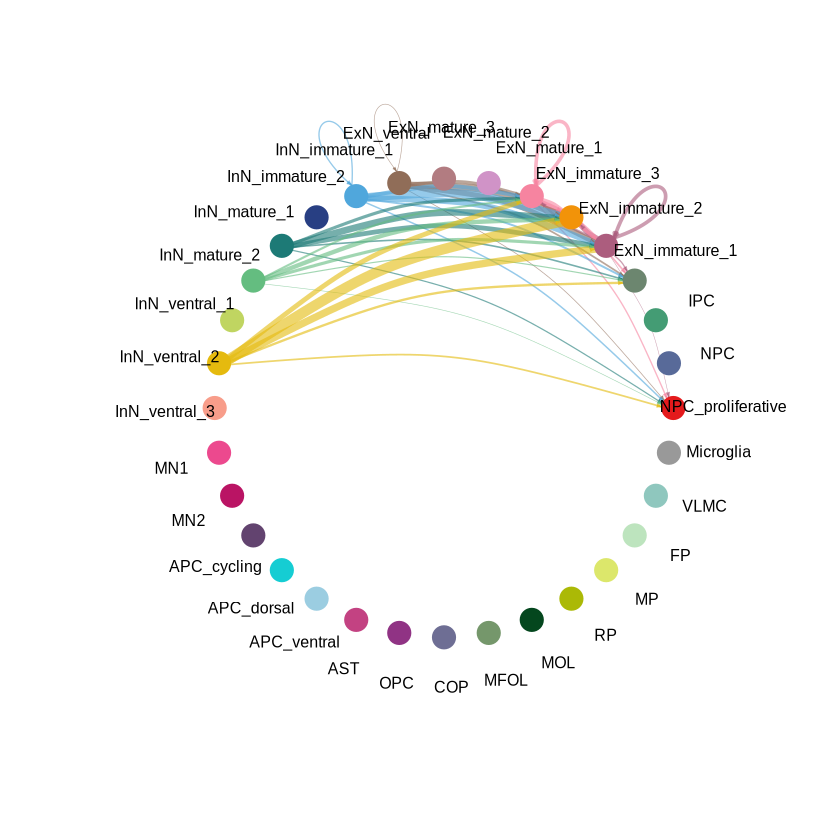

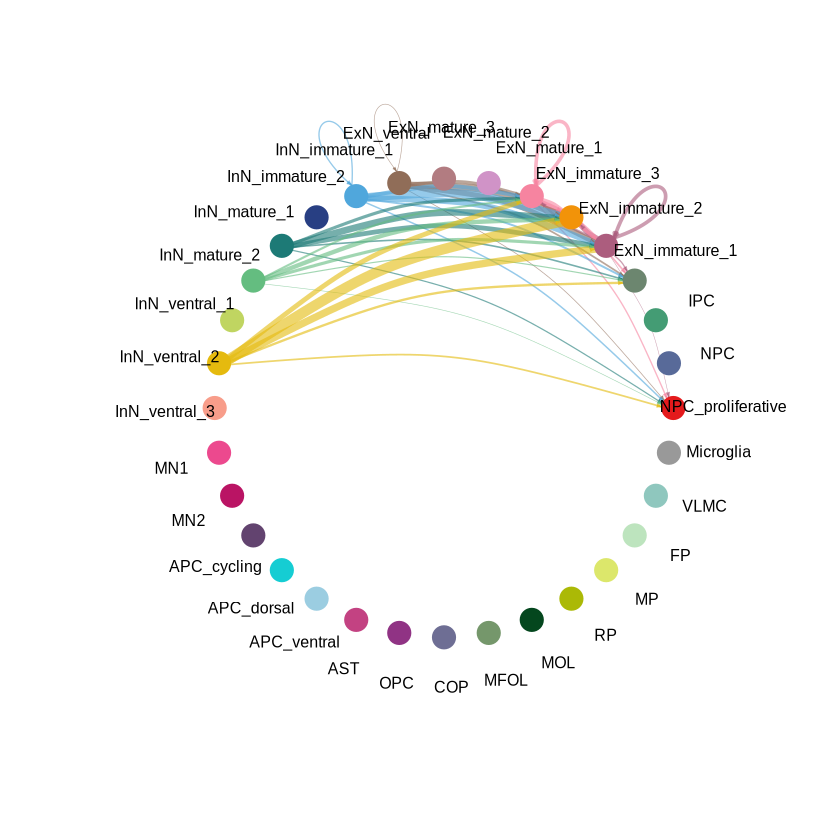

In [32]:
pathways.show <- c("NRG")
netVisual_aggregate(cellchat2, signaling = pathways.show, layout = "circle", remove.isolate = F)

pdf 
  2

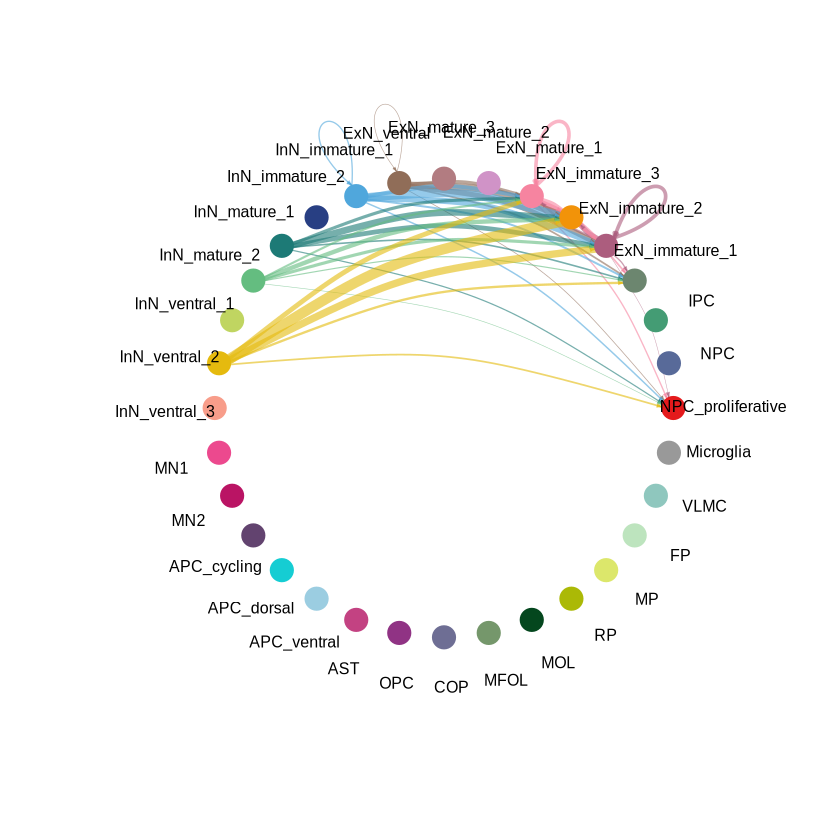

In [33]:
p <- netVisual_aggregate(cellchat2, signaling = pathways.show, layout = "circle", remove.isolate = F)
pdf(paste0("plot/circle_", pathways.show, ".pdf"), width = 7, height = 7.5)
print(p)  # Explicitly print recordedplot
dev.off()

## chord

In [34]:
# Define cellType order
# cellType = c(
#     "NPC_proliferative", "NPC", "dIPC", "vIPC",  #Neural_progenitor
#     "ExN_naive", "ExN_immature_1", "ExN_immature_2", "ExN_immature_3", "ExN_mature_1", "ExN_mature_2", "ExN_mature_3",  #Excitatory
#     "InN_naive", "InN_immature_1", "InN_immature_2", "InN_mature_1", "InN_mature_2", "InN_ventral_like",   #Inhibitory
#     "ventral_unknow", "v0_1", "v2a_b",   #Ventral Neuron
#     "MN1", "MN2",  #Motor_neuron
#     "dorsal_glia", "ventral_glia", "AST", "OPC", "COP", "MFOL", "MOL",  #Glia
#     "Ependymal", "FP", "RP",  #Ependymal
#     "Microglia",  #Microglia
#     "VLMC"  #VLMC
# )
cellType = c(
    "NPC_proliferative", "NPC", "IPC",  # Neural_progenitor
    "ExN_immature_1", "ExN_immature_2", "ExN_immature_3", "ExN_mature_1", "ExN_mature_2", "ExN_mature_3", "ExN_ventral",  # Excitatory
    "InN_immature_1", "InN_immature_2", "InN_mature_1", "InN_mature_2", "InN_ventral_1", "InN_ventral_2", "InN_ventral_3", #Inhibitory
    "MN1", "MN2", #Motor_neuron
    "APC_cycling", "APC_dorsal", "APC_ventral", "AST", #Astrocyte
    "OPC", "COP", "MFOL", "MOL",  #OLIGODENDROCYTE
    "RP", "MP", "FP",  #Ependymal
    "VLMC",  #VLMC
    "Microglia"  #Microglia
)
levels(cellchat@idents) <- cellType

In [35]:
# "group" only worked for chord diagram
# group.cellType <- c(rep("NPC", 4), rep("Ex", 7), rep("In", 6), rep("Vn", 3), rep("MN", 2), rep("Glia", 7), rep("Ependymal", 3),rep("Microglia", 1), rep("VLMC", 1))
# names(group.cellType) <- levels(cellchat@idents)
# group.cellType

group.cellType <- c(rep("NPC", 3), rep("Ex", 7), rep("In", 7), rep("MN", 2), rep("AST", 4), rep("Glia", 4), rep("Ependymal", 3), rep("VLMC", 1), rep("Microglia", 1))
names(group.cellType) <- levels(cellchat@idents)
group.cellType

NPC_proliferative               NPC               IPC    ExN_immature_1 
            "NPC"             "NPC"             "NPC"              "Ex" 
   ExN_immature_2    ExN_immature_3      ExN_mature_1      ExN_mature_2 
             "Ex"              "Ex"              "Ex"              "Ex" 
     ExN_mature_3       ExN_ventral    InN_immature_1    InN_immature_2 
             "Ex"              "Ex"              "In"              "In" 
     InN_mature_1      InN_mature_2     InN_ventral_1     InN_ventral_2 
             "In"              "In"              "In"              "In" 
    InN_ventral_3               MN1               MN2       APC_cycling 
             "In"              "MN"              "MN"             "AST" 
       APC_dorsal       APC_ventral               AST               OPC 
            "AST"             "AST"             "AST"            "Glia" 
              COP              MFOL               MOL                RP 
           "Glia"            "Glia"            "Glia"       "Ependymal" 
               MP                FP              VLMC         Microglia 
      "Ependymal"       "Ependymal"            "VLMC"       "Microglia"

pdf 
  2

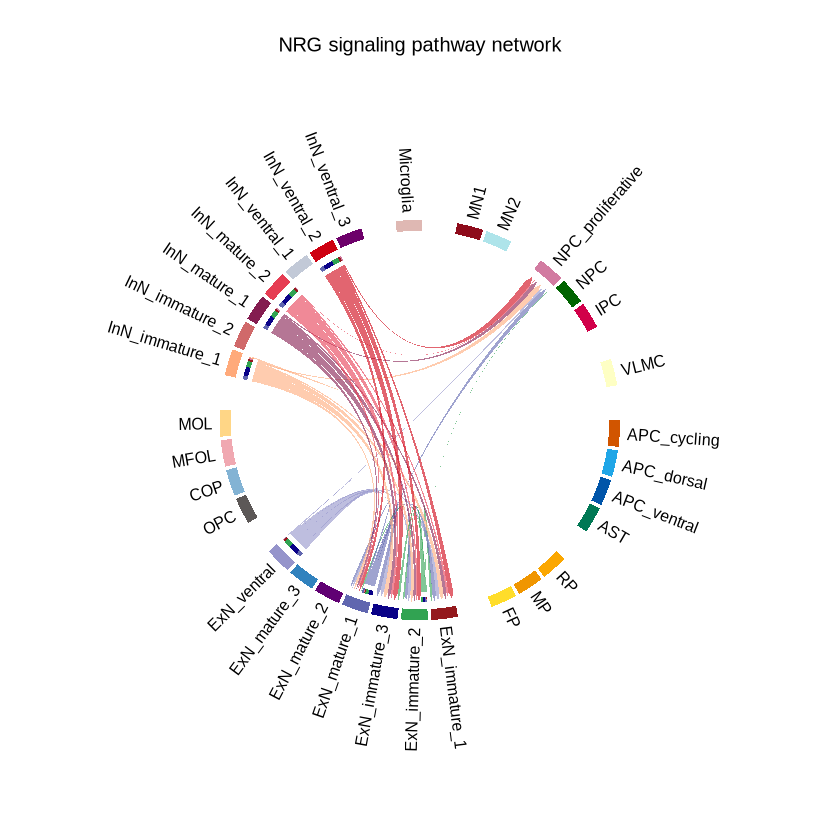

In [36]:
# Chord diagram
p <- netVisual_aggregate(cellchat2, signaling = pathways.show, color.use = color_list, group = group.cellType, layout = "chord", scale = F)
pdf(paste0("plot/chord_", pathways.show, ".pdf"), width = 7, height = 7.5)
print(p)  # Explicitly print recordedplot
dev.off()

## bubble


Attaching package: ‘gridExtra’


The following object is masked from ‘package:Biobase’:

    combine




The following object is masked from ‘package:BiocGenerics’:

    combine


The following object is masked from ‘package:dplyr’:

    combine


Comparing communications on a single object 


Comparing communications on a single object 


Comparing communications on a single object 




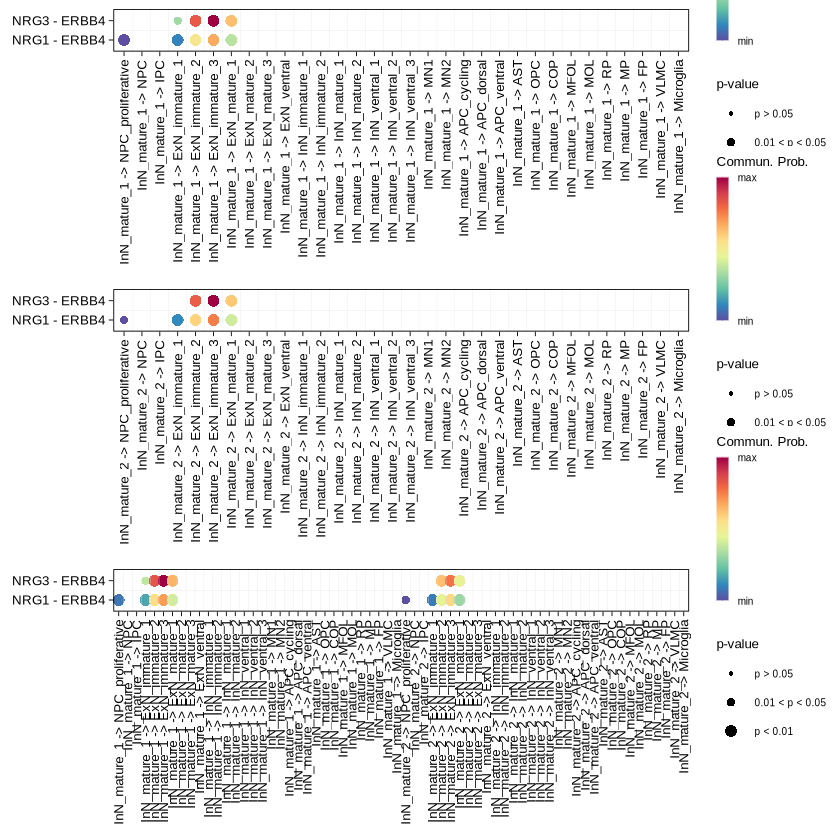

In [37]:
# Load required packages
library(gridExtra)  # For combining multiple plots

# Create three different plots
p1 <- netVisual_bubble(cellchat2, 
                      sources.use = 13,  # 13, InN_mature_1, NRG
                      targets.use = c(1:32), 
                      signaling = pathways.show, 
                      remove.isolate = FALSE)

p2 <- netVisual_bubble(cellchat2, 
                      sources.use = 14,  # 14, InN_mature_2
                      targets.use = c(1:32), 
                      signaling = pathways.show, 
                      remove.isolate = FALSE)

p3 <- netVisual_bubble(cellchat2, 
                      sources.use = c(13,14),  # 13, InN_mature_1; 14, InN_mature_2
                      targets.use = c(1:32), 
                      signaling = pathways.show, 
                      remove.isolate = FALSE)

# Arrange three plots vertically
combined_plot <- grid.arrange(p1, p2, p3, ncol = 1)

# Save combined figure into a single PDF
ggsave(
  filename = paste0("plot/bubble_", pathways.show, ".pdf"),
  plot = combined_plot,
  device = "pdf",
  width = 7,        # Adjust width to fit three plots
  height = 7,     # Increase height to contain three plots
  units = "in",
  dpi = 300
)

# heatmap all

In [38]:
p <- netVisual_heatmap(cellchat2, color.use = color_list, measure = "count", color.heatmap = "Reds")
pdf(paste0("plot/heatmap_celltype.pdf"), width = 7, height = 7)
print(p)
dev.off()

Do heatmap based on a single object 




pdf 
  2

In [39]:
# Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways
ht1 <- netAnalysis_signalingRole_heatmap(cellchat2, color.use = color_list, pattern = "outgoing")

pdf(paste0("plot/heatmap_Signaling_outgoing.pdf"), width = 7, height = 8.5)
print(ht1)
dev.off()

ht2 <- netAnalysis_signalingRole_heatmap(cellchat2, color.use = color_list, pattern = "incoming")
pdf(paste0("plot/heatmap_Signaling_incoming.pdf"), width = 7, height = 8.5)
print(ht2)
dev.off()

pdf 
  2

pdf 
  2

# Batch drawing

In [40]:
pathways.show.all <- cellchat2@netP$pathways
pathways.show.all

[1] "NCAM"          "PTN"           "PCDH"          "NRXN"         
 [5] "CypA"          "CD99"          "MK"            "ADGRL"        
 [9] "ADGRG"         "NEGR"          "SLIT"          "NRG"          
[13] "PTPR"          "CNTN"          "GAP"           "CADM"         
[17] "SOMATOSTATIN"  "COLLAGEN"      "L1CAM"         "Prostaglandin"
[21] "Glutamate"     "CDH"           "LAMININ"       "NGL"          
[25] "CLDN"          "SPP1"          "Netrin"        "PSAP"         
[29] "IGF"           "OPIOID"        "PTPRM"         "MAG"          
[33] "AGRN"          "NOTCH"         "Cholesterol"   "JAM"          
[37] "MPZ"           "CD46"          "FLRT"          "FN1"          
[41] "SEMA6"

In [41]:
for (i in 1:length(pathways.show.all)) {
    pathway <- pathways.show.all[i]
    
    # First check whether significant communication exists
    pairLR <- searchPair(
        signaling = pathway,
        pairLR.use = cellchat2@LR$LRsig,
        key = "pathway_name",
        matching.exact = TRUE,
        pair.only = TRUE
    )
    
    # Extract prob and pval for current pathway
    prob_subset <- cellchat2@net$prob[,, rownames(pairLR), drop = FALSE]
    pval_subset <- cellchat2@net$pval[,, rownames(pairLR), drop = FALSE]
    
    # Filter non-significant values
    prob_subset[pval_subset > 0.05] <- 0
    
    # Compute probability sum matrix
    prob.sum <- apply(prob_subset, c(1,2), sum)
    
    # Plot only when significant communication exists
    if (sum(prob.sum) > 0) {
        pdf(paste0("plot/circle_", pathway, ".pdf"), width = 7, height = 8)
        par(mfrow=c(1,1))
        
        tryCatch({
            netVisual_aggregate(
                cellchat2, 
                signaling = pathway, 
                color.use = color_list, 
                layout = "circle", 
                remove.isolate = F
            )
        }, error = function(e) {
            message(sprintf("Error plotting pathway '%s': %s", pathway, e$message))
        })
        
        dev.off()
    } else {
        message(sprintf("Skip pathway '%s': No significant communication", pathway))
    }
}

Skip pathway 'OPIOID': No significant communication

Skip pathway 'CD46': No significant communication

Skip pathway 'FLRT': No significant communication

Skip pathway 'FN1': No significant communication

